<a href="https://colab.research.google.com/github/gudzen2517/colabe/blob/main/autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install keras

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

file_path = 'dataset_2.csv'
dataframe = pd.read_csv(file_path)

dataframe['timestamp'] = pd.to_datetime(dataframe['timestamp'])
dataframe['timestamp'] = dataframe['timestamp'].rank(method='dense').astype(int)
unique_video_ids = dataframe['video_id'].nunique()

print(f"Количество уникальных video_id: {unique_video_ids}")
total_rows = len(dataframe)
print(f"Общее количество строк: {total_rows}")

grouped_data = dataframe.groupby('video_id')

#d = np.histogram(data)
#plt.hist(d[0], bins=100000, color='blue', edgecolor='blue')
#plt.show()

Количество уникальных video_id: 3715
Общее количество строк: 213520


In [ ]:
from keras.api import layers
from keras.api.models import Model

def get_autoencoder():
    input_layer = tf.keras.layers.Input(shape=(1,))
    encoded = tf.keras.layers.Dense(8,activation='relu')(input_layer)
    encoded = tf.keras.layers.Dense(6, activation='relu',)(encoded)
    encoded = tf.keras.layers.Dense(4, activation='relu')(encoded)
    decoded = tf.keras.layers.Dense(6, activation='relu')(encoded)
    decoded = tf.keras.layers.Dense(8, activation='relu')(decoded)
    output_layer = tf.keras.layers.Dense(1, activation='linear')(decoded)

    autoencoder = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

def auto():
    model = tf.keras.models.Sequential([
        layers.Dense(16, activation="relu", input_shape=(1,)),
        layers.Dense(8, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='mse')

    return model

In [ ]:
data = dataframe.values
size_ = data.shape
arr_numeric = data.astype(np.float64)
nan_mask = np.isnan(arr_numeric)
data = data[~nan_mask]
print(size_, data.shape)

test_data = data[:int(data.shape[0]*0.2)]
train_data = data[int(data.shape[0]*0.2):]




ValueError: could not convert string to float: 'ow'

In [ ]:
def norm(data : np.ndarray):
  return abs((data - np.mean(data)) / np.std(data))

def norm_test(data : np.ndarray, data_tr):
  return abs((data - np.mean(data_tr)) / np.std(data_tr))

test_data = norm_test(test_data, train_data)
train_data = norm(train_data)


train_data = tf.cast(train_data.astype(float), tf.float32)
test_data = tf.cast(test_data.astype(float), tf.float32)
autoencoder = auto()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.5592
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5573
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5554
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5533
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5512
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5490
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.5470
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5450
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5431
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.5412
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.5394
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.5376
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.5359
Epoch 14/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.5344
Epoch 15/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.5330
Epoch 16/20
1/1 ━━━━━━━━━━━━━━━━━━━━

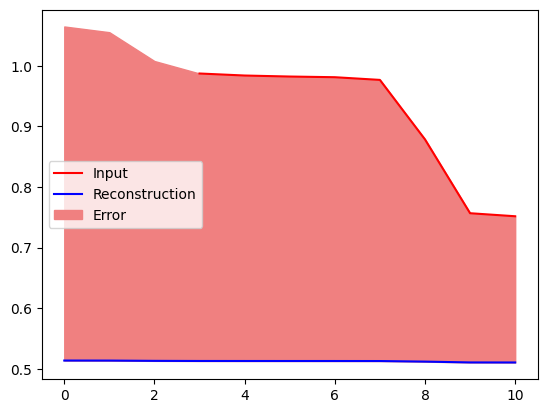

In [ ]:
autoencoder.fit(train_data, train_data,
                          epochs=20,
                          batch_size=128,
                          shuffle=False)
decoded_data = autoencoder.predict(test_data)
"""
mse = np.mean(np.square(train_data - decoded_data), axis=1)

# Calculate IQR for reconstruction errors
Q1 = np.quantile(mse, 0.25)
Q3 = np.quantile(mse, 0.75)
IQR = Q3 - Q1

# Define anomaly detection bounds based on reconstruction error IQR
lower_bound_re = Q1 - 5 * IQR
upper_bound_re = Q3 + 5 * IQR

# Determine anomalies based on the bounds
anomalies = ow_data[(ow_data < lower_bound_re) |
                                      (ow_data > upper_bound_re)]

print("Number of anomalies detected:", anomalies.shape[0])
"""
print(np.max(test_data), np.max(decoded_data))
masked_data = np.ma.masked_where(test_data >= 1, test_data)
plt.plot(masked_data, 'r')
plt.plot(decoded_data, 'b')
plt.fill_between(np.arange(len(masked_data)), np.asarray(decoded_data).reshape(-1), np.asarray(test_data), color='lightcoral')
plt.legend(labels=["Input", "Reconstruction", "Error"])
plt.show()